# 🛍️ Customer Segmentation using K-Means Clustering

## 🧾 Project Overview
Customer segmentation is a key strategy used by businesses to divide customers into distinct groups based on their behavior and characteristics.

In this project, we apply unsupervised learning techniques to group mall customers based on their annual income and spending habits.

---

## 🎯 Objectives
- Perform exploratory data analysis (EDA)
- Apply K-Means clustering to segment customers
- Use dimensionality reduction for visualization
- Provide business insights and marketing strategies

---

## 📂 Dataset Description
The dataset contains customer information including:

- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1–100)

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering
from sklearn.cluster import KMeans

# Scaling
from sklearn.preprocessing import StandardScaler

# Dimensionality reduction
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\Intrenship Assingment_2\Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 🔍 Exploratory Data Analysis

In this section, we explore the dataset to understand customer characteristics and identify patterns.

We focus on key variables such as age, income, and spending score.

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

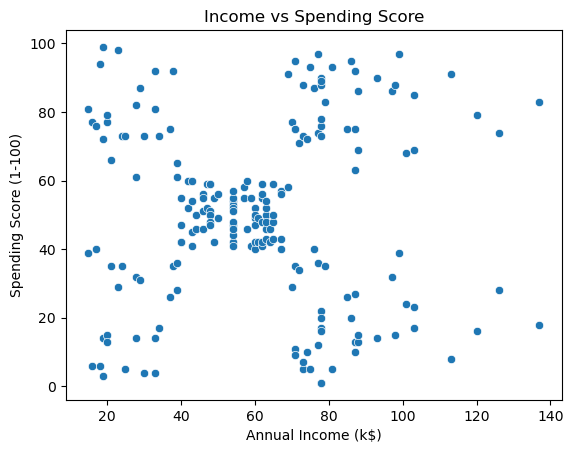

In [4]:
# Income vs Spending
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

## ⚙️ Data Preprocessing

Before clustering, we select relevant features and scale the data to ensure fair contribution from all variables.

In [5]:
# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 📉 Finding Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters by analyzing inertia.

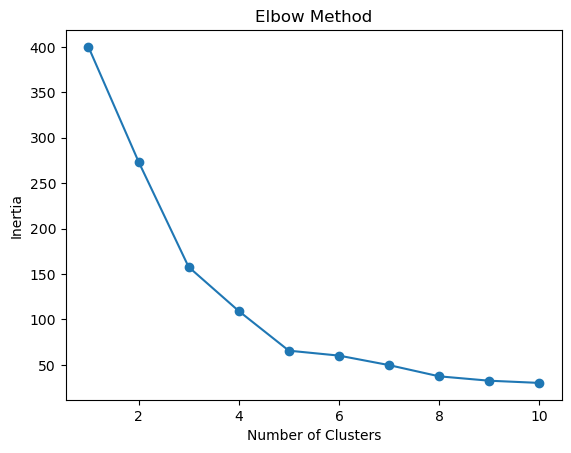

In [9]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

## 🤖 K-Means Clustering

Based on the Elbow Method, we apply K-Means clustering to segment customers.

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

## 🎨 Cluster Visualization

We visualize the clusters to understand how customers are grouped based on income and spending behavior.


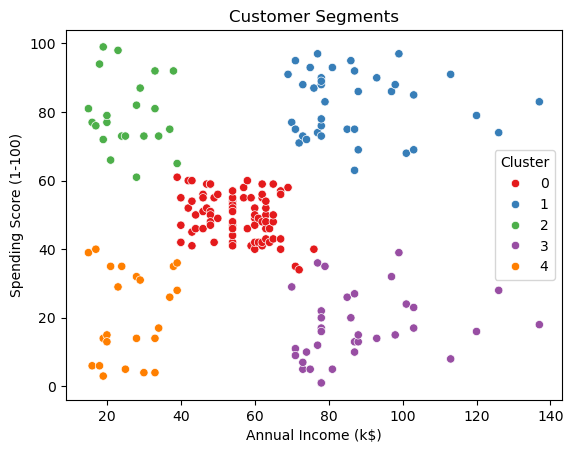

In [11]:
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    data=df,
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

## 🧠 Dimensionality Reduction (PCA)

PCA is used to reduce dimensions and visualize clustering in a simplified form.

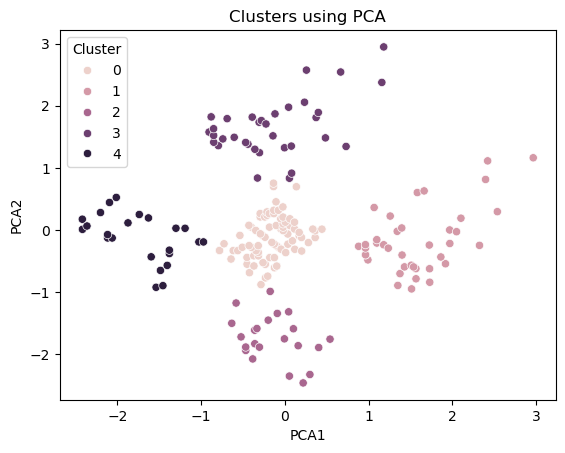

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df)
plt.title("Clusters using PCA")
plt.show()

## 💡 Business Insights & Marketing Strategy

Based on clustering results:

### Cluster 0: High Income, High Spending
- Target with premium products
- Offer loyalty programs

### Cluster 1: Low Income, High Spending
- Focus on discounts and promotions

### Cluster 2: High Income, Low Spending
- Encourage spending through personalized offers

### Cluster 3: Average Customers
- Maintain engagement with regular campaigns

### Cluster 4: Low Income, Low Spending
- Budget-friendly marketing strategies

## ✅ Conclusion

K-Means clustering successfully segmented customers into distinct groups based on their spending behavior and income.

These insights can help businesses design targeted marketing strategies, improving customer satisfaction and revenue.